# Missing Value

In [28]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


Menghitung jumlah data yang hilang (NaN) di setiap kolom untuk memahami kualitas
dataset.

In [29]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

Menghitung persentase data yang hilang untuk mengevaluasi apakah perlu dihapus atau
diisi ulang.

In [30]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

df.dropna digunakan untuk menghapus baris atau kolom yang memiliki missing values.

In [31]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


df.dropna(axis=1) digunakan untuk menghapus kolom yang memiliki missing values (NaN).

In [32]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


thresh = 5 berarti hanya baris yang memiliki minimal 5 nilai valid yang dipertahankan.
Contohnya baris indeks 2 hilang karena pada indeks tersebut nilai yang tidak berisi NaN
kurang dari 5.

In [33]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


Dengan menambahkan subset 'Age', maka hanya baris yang berisi NaN di kolom Age yang
dihapus

In [34]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


Menghapus kolom Blood Type dengan df.drop()

In [35]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


.fillna() digunakan untuk mengisi nilai yang kosong (missing values). Imputasi nilai bisa
menggunakan beberapa metode statistik seperti mean, median, mode.

Missing value pada kolom Age akan diisi dengan nilai rata-rata atau mean, Shoe Chart
dengan median, dan Fav Fruit dengan mode

In [36]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median()) digunakan untuk mengisi nilai yang kosong (NaN) pada kolom Shoe Chart dengan nilai median dari kolom tersebut.

In [37]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0]) digunakan untuk mengisi nilai kosong (NaN) pada kolom Fav Fruit dengan nilai yang paling sering muncul (modus).

In [38]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


Selain itu, missing value bisa juga diisi dengan back fill dan forward fill. Back fill untuk
mengisi nilai kosong di "Shoe Chart" dengan nilai dari bawahnya atau setelahnya. Forward
fill ntuk mengisi nilai kosong di "Fav Fruit" dengan nilai sebelumnya.

In [39]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill() digunakan untuk mengganti nilai kosong ("") menjadi None, kemudian mengisi nilai kosong tersebut dengan nilai sebelumnya (forward fill).

In [40]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


 # Outliers

In [41]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


Mendeteksi outliers secara visual dengan menggunakan boxplot dari seaborn dan
menghapus outliers dengan menggunakan Interquartile Range.
Outliers berada di luar titik whiskers pada boxplot.

<Axes: ylabel='Height'>

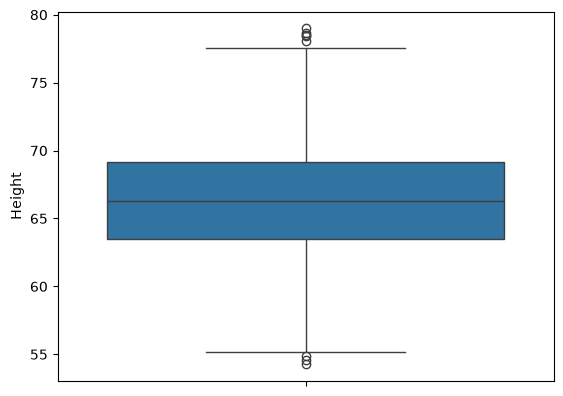

In [42]:
import seaborn as sns
sns.boxplot(df2['Height'])

Digunakan untuk mendeteksi dan menghapus outlier pada kolom `Height` menggunakan metode IQR, lalu menampilkan hasilnya dalam boxplot.

<Axes: ylabel='Height'>

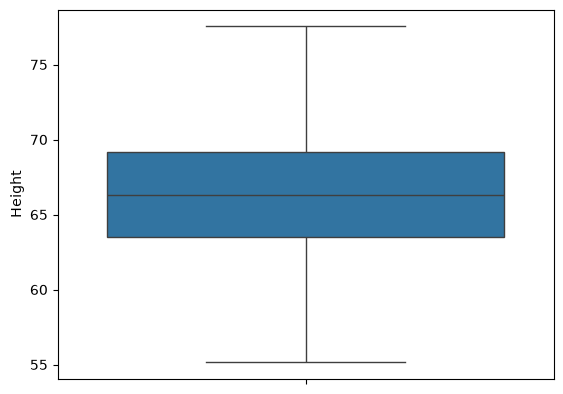

In [43]:
import numpy as np
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Height'] >= lower_bound)
& (df2['Height'] <= upper_bound)]
sns.boxplot(clean_data['Height'])

Digunakan untuk menampilkan boxplot pada kolom `Weight` untuk melihat distribusi data dan mendeteksi adanya outlier.

<Axes: ylabel='Weight'>

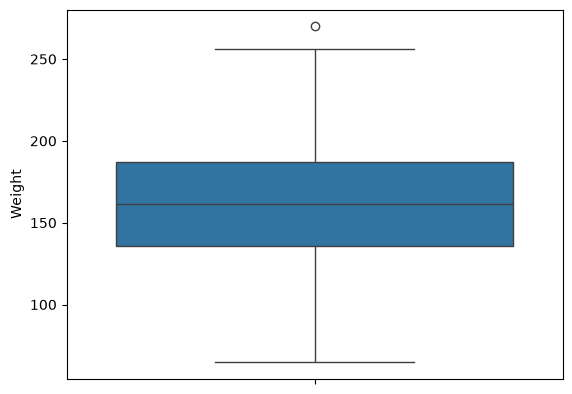

In [44]:
sns.boxplot(df2['Weight'])

Digunakan untuk mendeteksi dan menghapus outlier pada kolom `Weight` menggunakan metode IQR, kemudian menampilkan data yang sudah bersih dalam bentuk boxplot.

<Axes: ylabel='Weight'>

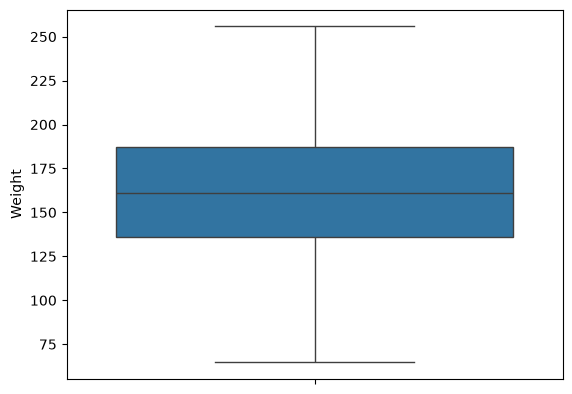

In [45]:
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Weight'] >= lower_bound)
                & (df2['Weight'] <= upper_bound)]
sns.boxplot(clean_data['Weight'])

Mendeteksi outliers dengan visualisasi dari matplotlib

C:\Users\User\AppData\Local\Temp\ipykernel_14552\3575850643.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\User\AppData\Local\Temp\ipykernel_14552\3575850643.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


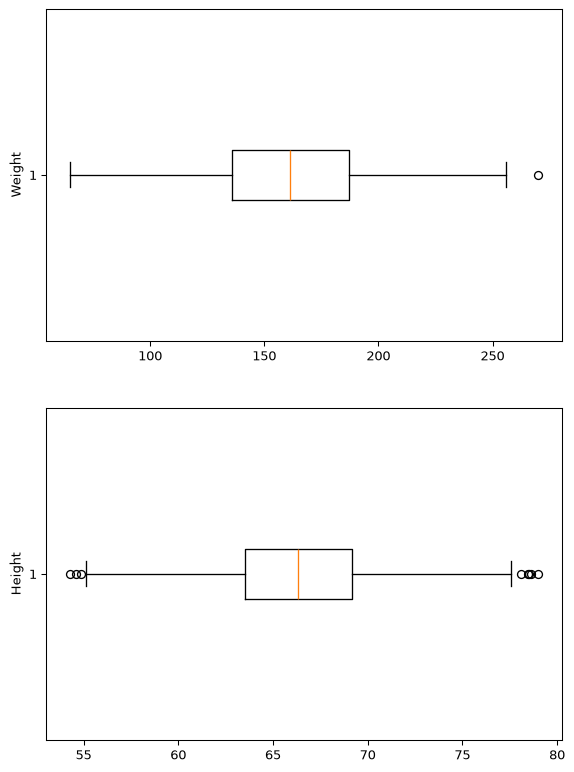

In [46]:
import matplotlib.pyplot as plt

# Membuat daftar kolom yang ingin dianalisis, yaitu "Weight" dan "Height".
columns_to_plot = ['Weight', 'Height']

# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

fig, axs = plt.subplots(
    len(columns_to_plot), 1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

Digunakan untuk menghapus outlier secara berurutan pada kolom `Height` dan `Weight` menggunakan metode IQR, lalu menampilkan boxplot dari data yang sudah dibersihkan untuk melihat hasil setelah outlier dihapus.

C:\Users\User\AppData\Local\Temp\ipykernel_14552\4157570040.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\User\AppData\Local\Temp\ipykernel_14552\4157570040.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


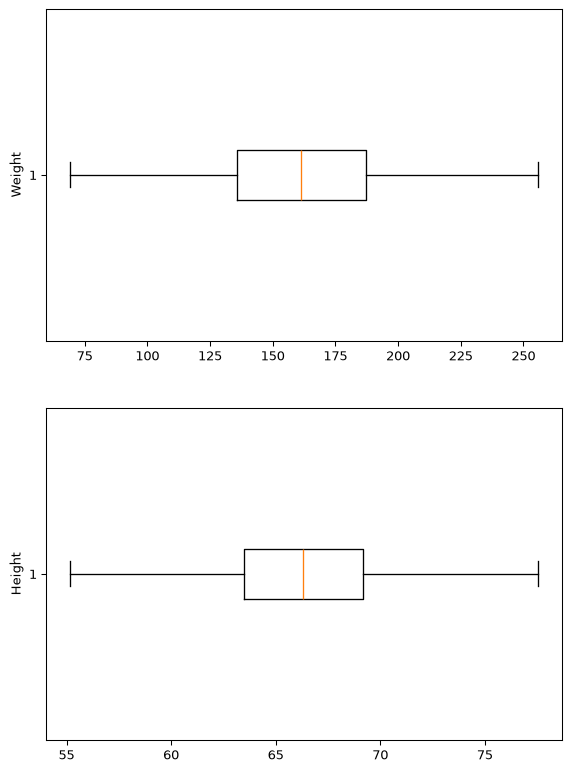

In [47]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) & 
            (df_cleaned[col] <= upper_bound)
        ]
    
    return df_cleaned


# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])


# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']

fig, axs = plt.subplots(
    len(columns_to_plot), 1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

Digunakan untuk mengubah skala semua kolom numerik pada `clean_data` menjadi rentang 0 sampai 1, sedangkan kolom non-numerik tidak ikut diubah. `fit_transform()` digunakan untuk menghitung nilai minimum-maksimum sekaligus melakukan proses scaling.

In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(include=[np.number]).columns  # Ambil kolom
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns  # Ambil k
rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[:]


array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

Digunakan untuk mengubah hasil scaling menjadi DataFrame, kemudian menggabungkannya kembali dengan kolom non-numerik sehingga menghasilkan `final_df` yang berisi seluruh data dengan kolom numerik sudah dalam skala 0–1.

In [49]:
# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(
    rescaled_numeric,
    columns=numeric_cols,
    index=clean_data.index
)

# Gabungkan kembali dengan kolom non-numerik tanpa mengubah jumlah baris
final_df = pd.concat(
    [clean_data[non_numeric_cols], rescaled_df],
    axis=1
)

final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


# Tugas - 2

In [50]:
import pandas as pd
# Load dataset
df = pd.read_csv('Titanic-Dataset.csv')

# Cek missing value sebelum diatasi
print("Missing value SEBELUM ditangani:")
print(df.isnull().sum())

# 1. Kolom 'Age' (numerik) isi dengan median
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Kolom 'Embarked' (kategorik) isi dengan modus (nilai paling sering muncul)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Kolom 'Cabin' missing-nya terlalu banyak (±77%), lebih baik didrop
df = df.drop(columns=['Cabin'])

# Cek missing value SETELAH diatasi
print("\nMissing value SETELAH ditangani:")
print(df.isnull().sum())

Missing value SEBELUM ditangani:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing value SETELAH ditangani:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


- Age diisi pakai median karena datanya numerik dan ada outlier (median lebih tahan terhadap outlier dibanding mean).
- Embarked diisi pakai modus karena datanya kategorik, cuma hilang 2 baris, jadi wajar diisi nilai yang paling sering muncul.
- Cabin langsung di-drop karena ~77% datanya kosong kalau dipaksa diisi, hasilnya justru bisa bias/tidak representatif.

# Tugas - 3

Saya memilih kolom: Insulin, SkinThickness, dan BMI (deteksi memakai boxplot seaborn).

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('diabetes.csv')

# Pilih 3 kolom untuk deteksi outlier
kolom_dicek = ['Insulin', 'SkinThickness', 'BMI']

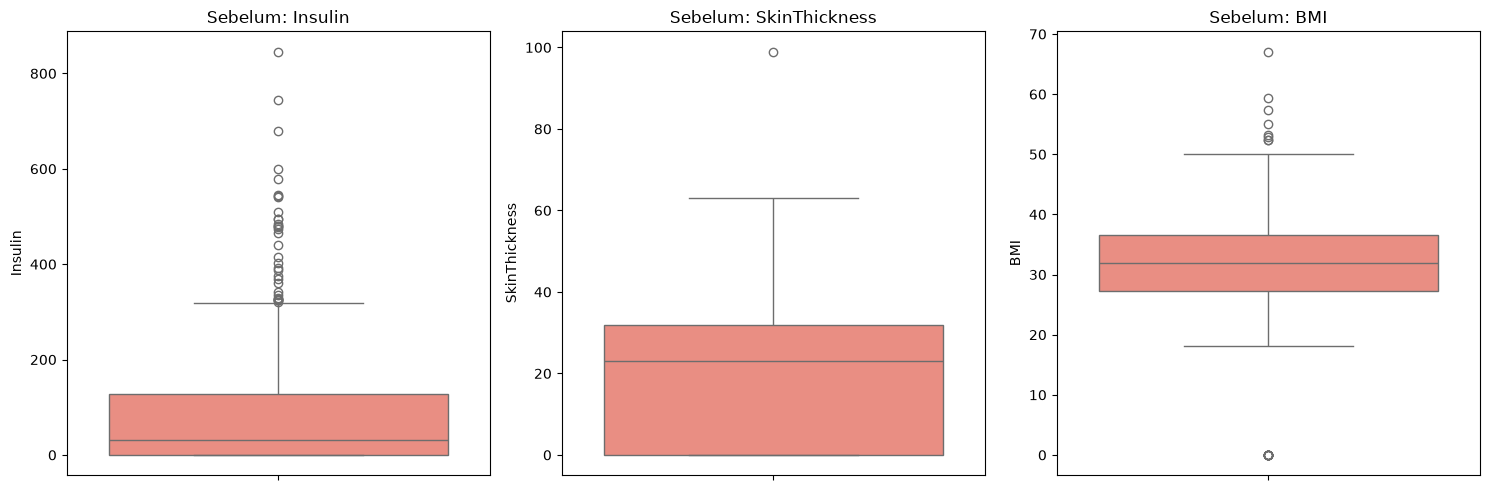

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, kolom in enumerate(kolom_dicek):
    sns.boxplot(y=df[kolom], ax=axes[i], color='salmon')
    axes[i].set_title(f'Sebelum: {kolom}')
plt.tight_layout()
plt.show()

In [57]:
for kolom in kolom_dicek:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    outlier = df[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas)]
    print(f"{kolom}: jumlah outlier = {len(outlier)}")

Insulin: jumlah outlier = 34
SkinThickness: jumlah outlier = 1
BMI: jumlah outlier = 19


Fungsi untuk menghapus outlier secara berurutan (kolom demi kolom) menggunakan metode IQR, agar data yang berada di luar batas bawah-atas dibuang.

In [58]:
def remove_outliers_sequentially(data, columns):
    data_cleaned = data.copy()
    for col in columns:
        Q1 = data_cleaned[col].quantile(0.25)
        Q3 = data_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data_cleaned = data_cleaned[(data_cleaned[col] >= lower) & (data_cleaned[col] <= upper)]
    return data_cleaned

# Terapkan fungsi untuk menghapus outlier dari 3 kolom terpilih
df_clean = remove_outliers_sequentially(df, kolom_dicek)

print(f"Jumlah baris sebelum dibersihkan: {len(df)}")
print(f"Jumlah baris sesudah dibersihkan : {len(df_clean)}")

Jumlah baris sebelum dibersihkan: 768
Jumlah baris sesudah dibersihkan : 715


Menampilkan boxplot sesudah outlier dihapus, untuk membuktikan bahwa outlier sudah berkurang/hilang dibanding sebelumnya.

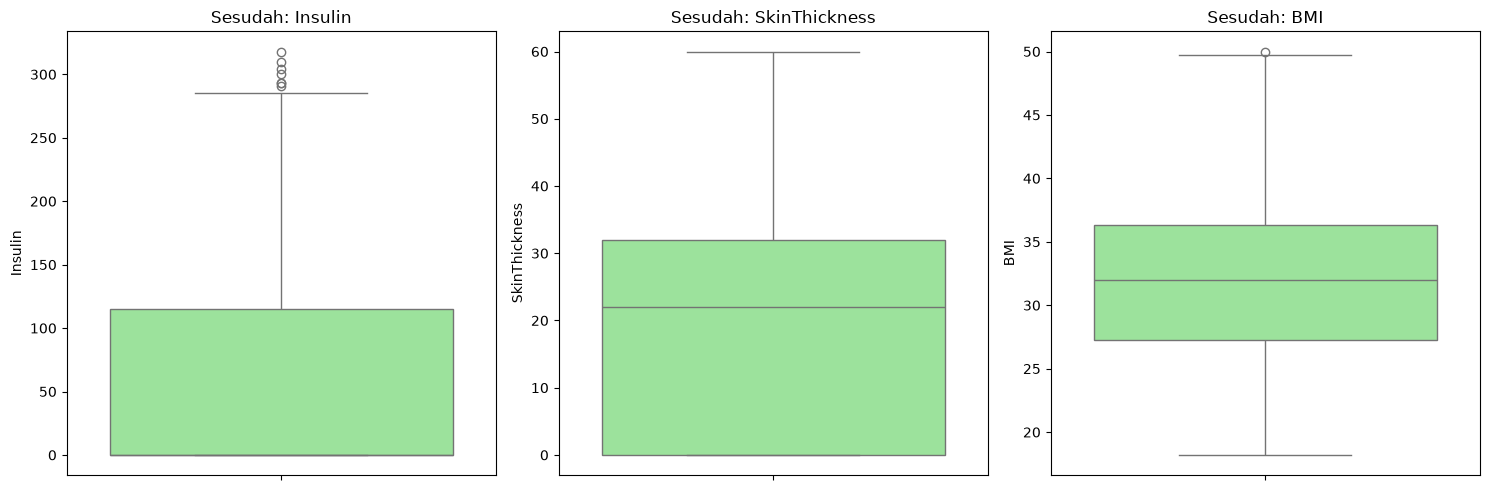

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, kolom in enumerate(kolom_dicek):
    sns.boxplot(y=df_clean[kolom], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Sesudah: {kolom}')
plt.tight_layout()
plt.show()

- Boxplot dipilih karena bisa langsung menunjukkan sebaran data (Q1, median, Q3) dan titik-titik di luar "whisker" itulah yang dianggap outlier.
- Insulin: outlier-nya paling banyak dan ekstrem, ada 34 data yang keluar batas (sampai nilai 800+, sementara mayoritas data di bawah 200).
- SkinThickness: cuma ada 1 outlier ekstrem (~99), sisanya sebarannya cukup rapat.
- BMI: ada 8 outlier, sebagian di atas (BMI tinggi >50) dan 1 nilai di bawah (BMI = 0, yang sebenarnya data tidak valid/missing yang disamarkan jadi 0).
- Metode deteksinya pakai IQR (Interquartile Range): titik dianggap outlier jika berada di luar rentang [Q1 - 1.5×IQR, Q3 + 1.5×IQR].
- Setelah outlier dihapus dari ketiga kolom itu, jumlah baris data berkurang dari 768 jadi 715, dan boxplot "sesudah" nunjukin bahwa sebarannya jauh lebih rapat, tidak ada lagi nilai yang mencolok ekstrem.

Catatan: nilai 0 di Insulin, SkinThickness, dan BMI itu sebenarnya bukan outlier asli, tapi missing value yang disamarkan jadi angka 0 (kan nggak mungkin BMI manusia = 0). Idealnya nilai 0 ini diganti dulu jadi NaN dan diisi lewat imputasi, bukan langsung dihapus pakai IQR, biar data yang sebenarnya valid tidak ikut terbuang.